In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [4]:
df = pd.read_csv("/content/Clinical Text Data.csv", encoding='latin1')
df.head()

,Id,Label,Text
0,0,Thyroid Research,Thyroid surgery in children in a single insti...
1,1,Thyroid Research,""" The adopted strategy was the same as that us..."
2,2,Thyroid Research,coronary arterybypass grafting thrombosis ï¬b...
3,3,Thyroid Research,Solitary plasmacytoma SP of the skull is an u...
4,4,Thyroid Research,This study aimed to investigate serum matrix ...


In [5]:
print(df.columns)
print(df.shape)
df['Label'].value_counts()

Index(['Id', 'Label', 'Text'], dtype='object')
(7501, 3)


,count
Label,
Thyroid Research,2810
Colorectal Studies,2511
Pulmonary Research,2180


In [8]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.lower()
    return text

def clean_stopword(text):
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

def tokenize(text):
    return word_tokenize(text)

In [9]:
df['final_text'] = df['Text'].apply(clean_text).apply(clean_stopword).apply(tokenize)
df.head()

,Id,Label,Text,final_text
0,0,Thyroid Research,Thyroid surgery in children in a single insti...,"[thyroid, surgery, children, single, instituti..."
1,1,Thyroid Research,""" The adopted strategy was the same as that us...","[adopted, strategy, used, prior, years, based,..."
2,2,Thyroid Research,coronary arterybypass grafting thrombosis ï¬b...,"[coronary, arterybypass, grafting, thrombosis,..."
3,3,Thyroid Research,Solitary plasmacytoma SP of the skull is an u...,"[solitary, plasmacytoma, sp, skull, uncommon, ..."
4,4,Thyroid Research,This study aimed to investigate serum matrix ...,"[study, aimed, investigate, serum, matrix, met..."


In [10]:
df['Label'] = df['Label'].astype('category').cat.codes

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    df['Text'], df['Label'], test_size=0.3, random_state=42
)
y_train = y_train.values
y_test = y_test.values

In [12]:
vectorizer = TfidfVectorizer(max_features=300)

X_trn = vectorizer.fit_transform(X_train).toarray()
X_vld = vectorizer.transform(X_test).toarray()


**What this does**

1. **`sample_rows`** – You can add or remove row numbers here without changing the rest of the code.
2. The loop checks `if idx < len(df)` to ensure each index exists.
3. **`" ".join(...)`** turns the list of tokens in `final_text` back into a single string for easy reading.




In [13]:
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(300,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(3, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
epochs = 15

history = model.fit(
    X_trn, y_train,
    validation_data=(X_vld, y_test),
    epochs=epochs,
    batch_size=64
)

Epoch 1/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.4944 - loss: 0.9906 - val_accuracy: 0.6917 - val_loss: 0.6136
Epoch 2/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7280 - loss: 0.5504 - val_accuracy: 0.7792 - val_loss: 0.4764
Epoch 3/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8119 - loss: 0.4163 - val_accuracy: 0.8223 - val_loss: 0.3983
Epoch 4/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8624 - loss: 0.3483 - val_accuracy: 0.7792 - val_loss: 0.4397
Epoch 5/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8377 - loss: 0.3430 - val_accuracy: 0.8663 - val_loss: 0.3009
Epoch 6/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8957 - loss: 0.2461 - val_accuracy: 0.8876 - val_loss: 0.2672
Epoch 7/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9129 - loss: 0.2135 - val_accuracy: 0.8965 - val_loss: 0.2450
Epoch 8/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9267 - loss: 0.1854 - val_accuracy: 0.9018 - val_loss

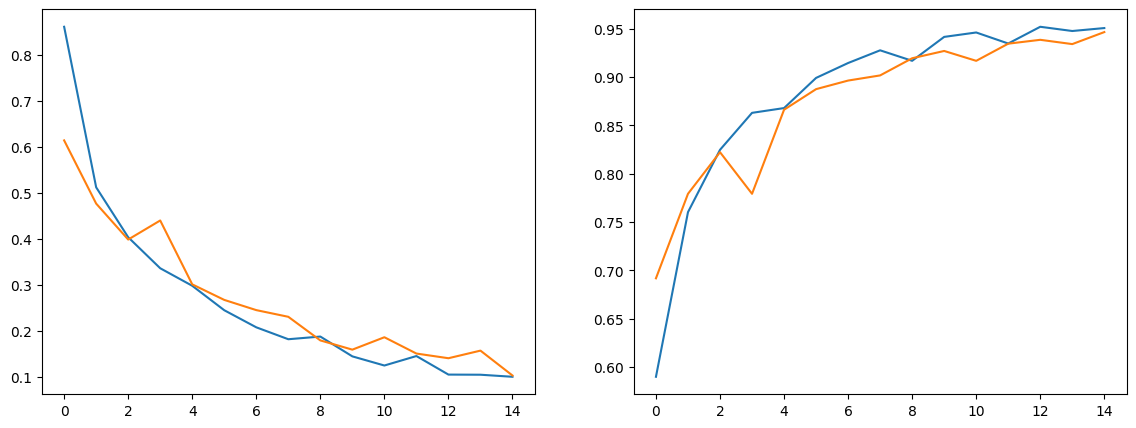

In [16]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.show()

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


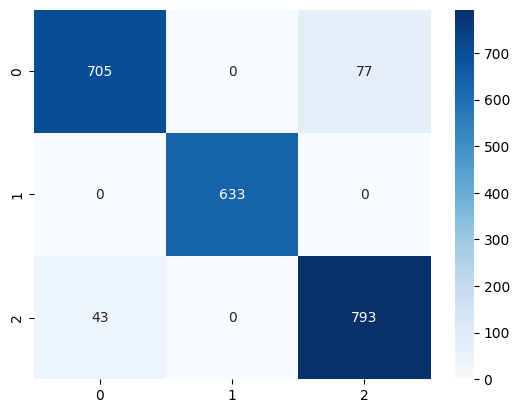

In [17]:
y_pred = model.predict(X_vld)
y_pred = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

In [23]:
import pickle

pickle.dump(model, open("model.pkl","wb"))
pickle.dump(vectorizer, open("vectorizer.pkl","wb"))

In [24]:
!pip install streamlit nltk --quiet

app_code = """
import streamlit as st
import numpy as np
import re
import pickle
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

# Load saved model + vectorizer
model = pickle.load(open("model.pkl","rb"))
vectorizer = pickle.load(open("vectorizer.pkl","rb"))

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z ]", "", text)
    return text

def clean_stopword(text):
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

labels = [
    "Thyroid Research",
    "Colorectal Studies",
    "Pulmonary Research"
]

def predict(text):

    if text.strip() == "":
        return "Please enter text"

    text_clean = clean_text(text)
    text_clean = clean_stopword(text_clean)

    # ML prediction
    vec = vectorizer.transform([text_clean]).toarray()
    pred = model.predict(vec)
    pred_class = np.argmax(pred)

    # ----- Quick keyword correction -----
    text_lower = text.lower()

    thyroid_keywords = ["thyroid", "tsh", "hormone", "thyroxine"]
    colorectal_keywords = ["colon", "colorectal", "colonoscopy", "polyp"]
    pulmonary_keywords = ["lung", "pulmonary", "copd", "asthma", "respiratory"]

    if any(k in text_lower for k in thyroid_keywords):
        pred_class = 0
    elif any(k in text_lower for k in colorectal_keywords):
        pred_class = 1
    elif any(k in text_lower for k in pulmonary_keywords):
        pred_class = 2

    return labels[pred_class]

st.set_page_config(page_title="Clinical Research Classifier")

st.title("🧬 Clinical Research Text Classification")

st.write("Enter a clinical research sentence to classify the research area.")

user_input = st.text_area(
    "Enter Clinical Text",
    placeholder="Example: Colonoscopy screening helps detect colorectal cancer early...",
    height=150
)

if st.button("Predict"):

    result = predict(user_input)

    st.success(f"Prediction: {result}")
"""

with open("app.py","w") as f:
    f.write(app_code)

print("Streamlit app created successfully")

Streamlit app created successfully


In [25]:
!streamlit run app.py --server.port 8501 &>/content/logs.txt &

In [26]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

import subprocess, time

time.sleep(5)

tunnel = subprocess.Popen(
    ["./cloudflared", "tunnel", "--url", "http://localhost:8501"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

for line in tunnel.stdout:
    if "https://" in line and "trycloudflare.com" in line:
        print("🚀 OPEN THIS LINK:", line.strip())
        break

cloudflared: Text file busy
🚀 OPEN THIS LINK: 2026-03-10T09:26:53Z INF |  https://simplified-adipex-meal-charlotte.trycloudflare.com                                |
